# CycleGAN — Monet Style Transfer
Trasforma foto reali in dipinti in stile Monet usando CycleGAN.

**Architettura:**
- 2 Generator ResNet (foto→Monet, Monet→foto)
- 2 Discriminator PatchGAN
- Loss: Adversarial + Cycle Consistency + Identity

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import uuid
import itertools
from torch.utils.data import RandomSampler

In [2]:
# ── Configurazione ──────────────────────────────────────────────
IMAGE_SIZE      = 256
BATCH_SIZE      = 4       # CycleGAN usa batch=1 per InstanceNorm
NUM_EPOCHS      = 25
OPTIMIZER_LR    = 0.0002
OPTIMIZER_BETAS = (0.5, 0.999)
LAMBDA_CYCLE    = 10.0    # peso cycle consistency loss
LAMBDA_IDENTITY = 5.0     # peso identity loss
N_RESIDUAL      = 9       # blocchi residuali nel Generator (9 per 256x256)
TRAIN_ON_GPU    = True
SAVE_EVERY      = 10      # salva modelli ogni N epoch
PRINT_EVERY     = 50      # stampa loss ogni N batch
UNIQUE_RUN_ID   = str(uuid.uuid4())

MONET_DIR = '/kaggle/input/competitions/gan-getting-started/monet_jpg'
PHOTO_DIR = '/kaggle/input/competitions/gan-getting-started/photo_jpg'

## Dataset

In [3]:
class ImageDataset(Dataset):
    """Carica immagini da una directory con transform opzionale."""
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.images    = sorted(os.listdir(directory))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        path  = os.path.join(self.directory, self.images[index])
        image = np.array(Image.open(path).convert('RGB'))
        if self.transform:
            image = self.transform(image)
        return image


class PairedDataset(Dataset):
    """
    Combina due dataset (Monet + foto) restituendo coppie casuali.
    Le coppie sono NON allineate — è CycleGAN, non Pix2Pix.
    La lunghezza è il max tra i due dataset.
    """
    def __init__(self, monet_dir, photo_dir, transform=None):
        self.monet = ImageDataset(monet_dir, transform)
        self.photo = ImageDataset(photo_dir, transform)

    def __len__(self):
        return max(len(self.monet), len(self.photo))

    def __getitem__(self, index):
        monet_img = self.monet[index % len(self.monet)]
        photo_img = self.photo[index % len(self.photo)]
        return monet_img, photo_img


def get_transform():
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),   # data augmentation
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])


def prepare_dataset():
    dataset    = PairedDataset(MONET_DIR, PHOTO_DIR, transform=get_transform())
    # Usa solo 400 campioni per epoch — abbastanza per imparare, molto più veloce
    sampler = RandomSampler(dataset, replacement=True, num_samples=400)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=sampler,
                            num_workers=4, pin_memory=True)
    print(f'Monet: {len(dataset.monet)} immagini | Foto: {len(dataset.photo)} immagini')
    return dataloader

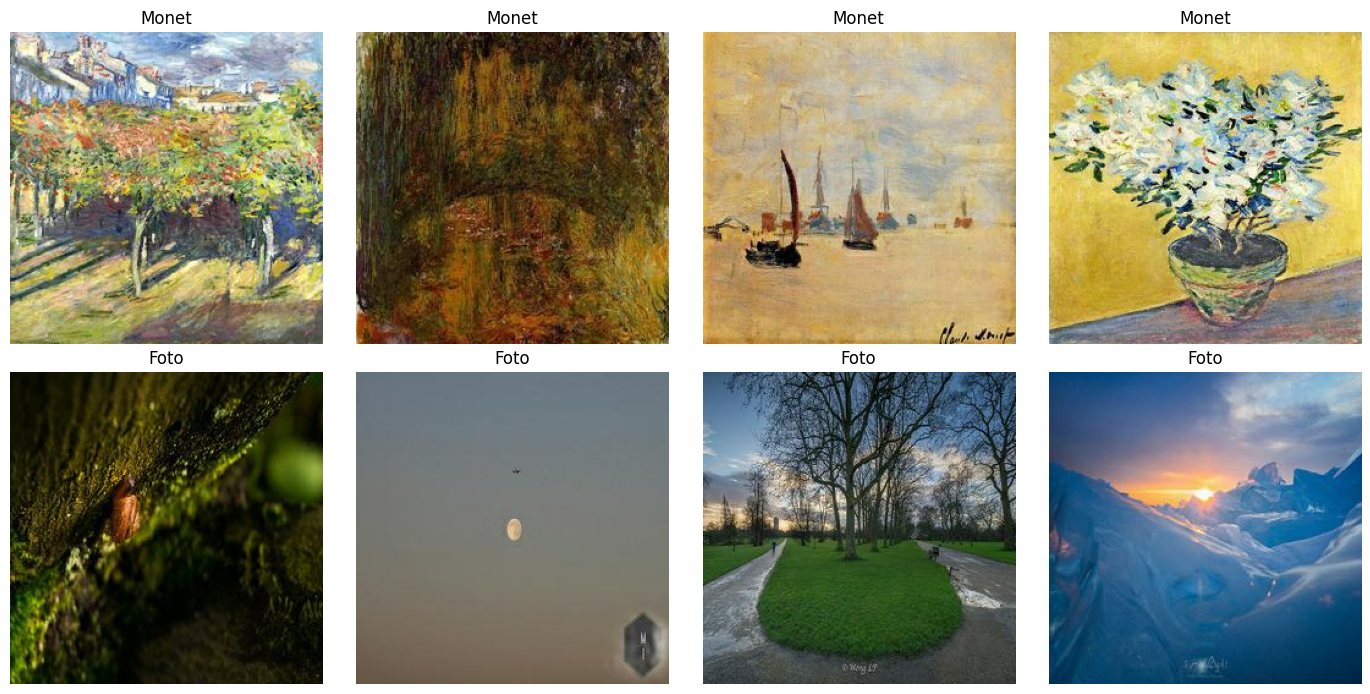

In [4]:
# Verifica visiva del dataset
transform  = get_transform()
monet_ds   = ImageDataset(MONET_DIR, transform)
photo_ds   = ImageDataset(PHOTO_DIR, transform)

def denorm(tensor):
    """Riporta da [-1,1] a [0,1] per plt.imshow."""
    return (tensor.cpu().detach().numpy().transpose(1,2,0) * 0.5 + 0.5).clip(0,1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(denorm(monet_ds[random.randint(0, len(monet_ds)-1)]))
    axes[0, i].set_title('Monet'); axes[0, i].axis('off')
    axes[1, i].imshow(denorm(photo_ds[random.randint(0, len(photo_ds)-1)]))
    axes[1, i].set_title('Foto');  axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## Architettura

### Generator (ResNet)
```
Input (3×256×256)
  → Encoder:    3 Conv con stride 2  → features 256×64×64 
  → Residual:   9 ResBlock           → features invariate
  → Decoder:    3 ConvTranspose      → output 3×256×256
  → Tanh
```

### Discriminator (PatchGAN)
Giudica patch 70×70 invece dell'immagine intera → più stabile, cattura texture locale.

In [5]:
class ResidualBlock(nn.Module):
    """Blocco residuale con InstanceNorm (standard CycleGAN)."""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, bias=False),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, bias=False),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)   # connessione residuale


class Generator(nn.Module):
    """
    ResNet Generator.
    n_residual=9 per immagini 256×256 (paper originale).
    """
    def __init__(self, n_residual=N_RESIDUAL):
        super().__init__()
        layers = [
            # ── Encoder ──────────────────────────────────
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, 64, 7, bias=False),          # 256 → 256
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),   # 256 → 128
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, stride=2, padding=1, bias=False),  # 128 → 64
            nn.InstanceNorm2d(256),
            nn.ReLU(inplace=True),
        ]
        # ── Residual blocks ───────────────────────────
        for _ in range(n_residual):
            layers.append(ResidualBlock(256))

        layers += [
            # ── Decoder ──────────────────────────────────
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1,      # 64 → 128
                               output_padding=1, bias=False),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1,       # 128 → 256
                               output_padding=1, bias=False),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ReflectionPad2d(3),
            nn.Conv2d(64, 3, 7),
            nn.Tanh()
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class Discriminator(nn.Module):
    """
    PatchGAN Discriminator — giudica patch 70×70.
    Output: mappa di probabilità (non un singolo scalare).
    """
    def __init__(self):
        super().__init__()

        def disc_block(in_ch, out_ch, normalize=True):
            layers = [nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_ch))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *disc_block(3,   64,  normalize=False),  # 256 → 128
            *disc_block(64,  128),                    # 128 → 64
            *disc_block(128, 256),                    # 64  → 32
            *disc_block(256, 512),                    # 32  → 16
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1)           # → mappa 16×16
            # Niente Sigmoid: usiamo MSELoss (LSGAN)
        )

    def forward(self, x):
        return self.model(x)

## Utility

In [6]:
def get_device():
    return torch.device('cuda:0' if torch.cuda.is_available() and TRAIN_ON_GPU else 'cpu')


def make_directory_for_run():
    print(f'Run ID: {UNIQUE_RUN_ID}')
    os.makedirs(f'./runs/{UNIQUE_RUN_ID}/images', exist_ok=True)


def efficient_zero_grad(model):
    for param in model.parameters():
        param.grad = None


def save_models(G_F2M, G_M2F, D_M, D_F, epoch):
    """Salva i 4 modelli ogni SAVE_EVERY epoch."""
    if epoch % SAVE_EVERY == 0 or epoch == NUM_EPOCHS - 1:
        base = f'./runs/{UNIQUE_RUN_ID}'
        torch.save(G_F2M.state_dict(), f'{base}/G_F2M_{epoch}.pth')
        torch.save(G_M2F.state_dict(), f'{base}/G_M2F_{epoch}.pth')
        torch.save(D_M.state_dict(),   f'{base}/D_M_{epoch}.pth')
        torch.save(D_F.state_dict(),   f'{base}/D_F_{epoch}.pth')
        print(f'  → Modelli salvati (epoch {epoch})')


def visualize_results(G_F2M, photo_batch, epoch, device):
    """Mostra 4 coppie foto → Monet generato."""
    G_F2M.eval()
    with torch.no_grad():
        fake_monet = G_F2M(photo_batch.to(device))
    G_F2M.train()

    n = min(4, photo_batch.size(0))
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8), squeeze=False)  # squeeze=False: axes sempre 2D anche con n=1
    for i in range(n):
        axes[0, i].imshow(denorm(photo_batch[i]))
        axes[0, i].set_title('Foto reale'); axes[0, i].axis('off')
        axes[1, i].imshow(denorm(fake_monet[i]))
        axes[1, i].set_title('Monet generato'); axes[1, i].axis('off')
    plt.suptitle(f'Epoch {epoch}')
    plt.tight_layout()
    plt.savefig(f'./runs/{UNIQUE_RUN_ID}/images/epoch_{epoch:03d}.jpg')
    plt.show()

## Training

### Le 3 loss di CycleGAN

**1. Adversarial loss (LSGAN)** — il Generator inganna il Discriminator:
```
L_adv = MSE(D_M(G_F2M(foto)), 1)   ← G vuole sembrare reale
```

**2. Cycle consistency loss** — foto→Monet→foto ≈ foto originale:
```
L_cycle = ||G_M2F(G_F2M(foto)) - foto||  ×  λ_cycle
```

**3. Identity loss** — se dai un Monet a G_F2M, deve restituire lo stesso Monet:
```
L_identity = ||G_F2M(monet) - monet||  ×  λ_identity
```

In [7]:
def initialize_models(device):
    G_F2M = Generator().to(device)   # foto → Monet
    G_M2F = Generator().to(device)   # Monet → foto
    D_M   = Discriminator().to(device)  # discrimina Monet reali vs falsi
    D_F   = Discriminator().to(device)  # discrimina foto reali vs false

    # Inizializzazione pesi (paper originale)
    def weights_init(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif isinstance(m, nn.InstanceNorm2d) and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

    for model in [G_F2M, G_M2F, D_M, D_F]:
        model.apply(weights_init)

    return G_F2M, G_M2F, D_M, D_F


def initialize_optimizers(G_F2M, G_M2F, D_M, D_F):
    # Un ottimizzatore condiviso per i 2 Generator
    opt_G = torch.optim.Adam(
        itertools.chain(G_F2M.parameters(), G_M2F.parameters()),
        lr=OPTIMIZER_LR, betas=OPTIMIZER_BETAS
    )
    opt_D_M = torch.optim.Adam(D_M.parameters(), lr=OPTIMIZER_LR, betas=OPTIMIZER_BETAS)
    opt_D_F = torch.optim.Adam(D_F.parameters(), lr=OPTIMIZER_LR, betas=OPTIMIZER_BETAS)
    return opt_G, opt_D_M, opt_D_F


def perform_train_step(G_F2M, G_M2F, D_M, D_F,
                       real_monet, real_photo,
                       opt_G, opt_D_M, opt_D_F,
                       criterion_GAN, criterion_cycle, criterion_identity,
                       device):

    real_monet = real_monet.to(device)
    real_photo = real_photo.to(device)

    # Target labels per LSGAN
    real_label = torch.ones(real_monet.size(0), 1, 16, 16, device=device)
    fake_label = torch.zeros(real_monet.size(0), 1, 16, 16, device=device)

    # ── 1. TRAINING GENERATORS ────────────────────────────────────
    efficient_zero_grad(G_F2M)
    efficient_zero_grad(G_M2F)

    fake_monet = G_F2M(real_photo)    # foto → Monet falso
    fake_photo = G_M2F(real_monet)    # Monet → foto falsa

    # Adversarial: i Generator vogliono ingannare i Discriminator
    loss_G_adv = (
        criterion_GAN(D_M(fake_monet), real_label) +
        criterion_GAN(D_F(fake_photo), real_label)
    )

    # Cycle consistency: foto→Monet→foto ≈ foto, Monet→foto→Monet ≈ Monet
    rec_photo = G_M2F(fake_monet)     # ricostruisce foto
    rec_monet = G_F2M(fake_photo)     # ricostruisce Monet
    loss_cycle = (
        criterion_cycle(rec_photo, real_photo) +
        criterion_cycle(rec_monet, real_monet)
    ) * LAMBDA_CYCLE

    # Identity: G_F2M(monet) ≈ monet  (preserva colori)
    loss_identity = (
        criterion_identity(G_F2M(real_monet), real_monet) +
        criterion_identity(G_M2F(real_photo), real_photo)
    ) * LAMBDA_IDENTITY

    loss_G = loss_G_adv + loss_cycle + loss_identity
    loss_G.backward()
    opt_G.step()

    # ── 2. TRAINING DISCRIMINATOR MONET ───────────────────────────
    efficient_zero_grad(D_M)
    loss_D_M = (
        criterion_GAN(D_M(real_monet), real_label) +
        criterion_GAN(D_M(fake_monet.detach()), fake_label)
    ) * 0.5
    loss_D_M.backward()
    opt_D_M.step()

    # ── 3. TRAINING DISCRIMINATOR FOTO ────────────────────────────
    efficient_zero_grad(D_F)
    loss_D_F = (
        criterion_GAN(D_F(real_photo), real_label) +
        criterion_GAN(D_F(fake_photo.detach()), fake_label)
    ) * 0.5
    loss_D_F.backward()
    opt_D_F.step()

    return loss_G.item(), loss_D_M.item(), loss_D_F.item()


def perform_epoch(dataloader, G_F2M, G_M2F, D_M, D_F,
                  opt_G, opt_D_M, opt_D_F,
                  criterion_GAN, criterion_cycle, criterion_identity,
                  epoch, device):

    G_F2M.train(); G_M2F.train(); D_M.train(); D_F.train()
    sample_photos = []  # accumula fino a 4 immagini (necessario con BATCH_SIZE=1)

    for batch_no, (real_monet, real_photo) in enumerate(dataloader):
        if len(sample_photos) < 4:
            sample_photos.append(real_photo)
        if len(sample_photos) == 4 and not isinstance(sample_photos, torch.Tensor):
            sample_photos = torch.cat(sample_photos, dim=0)  # [4, 3, 256, 256]

        loss_G, loss_D_M, loss_D_F = perform_train_step(
            G_F2M, G_M2F, D_M, D_F,
            real_monet, real_photo,
            opt_G, opt_D_M, opt_D_F,
            criterion_GAN, criterion_cycle, criterion_identity,
            device
        )

        if batch_no % PRINT_EVERY == 0:
            print(f'  Batch {batch_no:4d} | G: {loss_G:.4f} | D_M: {loss_D_M:.4f} | D_F: {loss_D_F:.4f}')

    # Visualizza risultati a fine epoch
    visualize_results(G_F2M, sample_photos, epoch, device)
    save_models(G_F2M, G_M2F, D_M, D_F, epoch)
    torch.cuda.empty_cache()

In [8]:
def train_cyclegan():
    make_directory_for_run()
    torch.manual_seed(42)

    device = get_device()
    print(f'Device: {device}')

    dataloader              = prepare_dataset()
    G_F2M, G_M2F, D_M, D_F = initialize_models(device)
    opt_G, opt_D_M, opt_D_F = initialize_optimizers(G_F2M, G_M2F, D_M, D_F)

    # Loss functions
    criterion_GAN      = nn.MSELoss()   # LSGAN — più stabile di BCELoss
    criterion_cycle    = nn.L1Loss()
    criterion_identity = nn.L1Loss()

    for epoch in range(NUM_EPOCHS):
        print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
        perform_epoch(
            dataloader, G_F2M, G_M2F, D_M, D_F,
            opt_G, opt_D_M, opt_D_F,
            criterion_GAN, criterion_cycle, criterion_identity,
            epoch, device
        )

    print(f'\nTraining completato! Run ID: {UNIQUE_RUN_ID}')
    return G_F2M, G_M2F


G_F2M, G_M2F = train_cyclegan()

Run ID: f6f7c8f8-c25c-47db-8c33-2d3705ce1a47
Device: cpu
Monet: 300 immagini | Foto: 7038 immagini

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Batch    0 | G: 21.8821 | D_M: 2.1132 | D_F: 1.8393


KeyboardInterrupt: 

## Generazione submission

La competizione richiede immagini generate in stile Monet. Usiamo `G_F2M` per trasformare le foto del test set.

In [ ]:
import zipfile

def generate_submission(G_F2M, device):
    """Genera 7000+ immagini Monet e le zippa per la submission."""
    output_dir = './images'
    os.makedirs(output_dir, exist_ok=True)

    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    photo_ds = ImageDataset(PHOTO_DIR, transform)
    loader   = DataLoader(photo_ds, batch_size=4, shuffle=False)

    G_F2M.eval()
    img_count = 0
    with torch.no_grad():
        for batch in loader:
            fake_monets = G_F2M(batch.to(device))
            for img_tensor in fake_monets:
                img_np = (img_tensor.cpu().numpy().transpose(1,2,0) * 0.5 + 0.5)
                img_np = (img_np.clip(0,1) * 255).astype(np.uint8)
                Image.fromarray(img_np).save(f'{output_dir}/{img_count:05d}.jpg')
                img_count += 1

    # Zip per submission Kaggle
    with zipfile.ZipFile('images.zip', 'w') as zf:
        for fname in os.listdir(output_dir):
            zf.write(os.path.join(output_dir, fname), fname)

    print(f'Submission pronta: {img_count} immagini in images.zip')


generate_submission(G_F2M, get_device())